In [34]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [35]:
columns = [
    "Id","RI","Na","Mg","Al",
    "Si","K","Ca","Ba","Fe","Type"
]

df = pd.read_csv("glass.data", header=None, names=columns)

df.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [36]:
X = df.drop(columns=["Id", "Type"])

In [37]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [38]:
wcss = []

for i in range(2, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

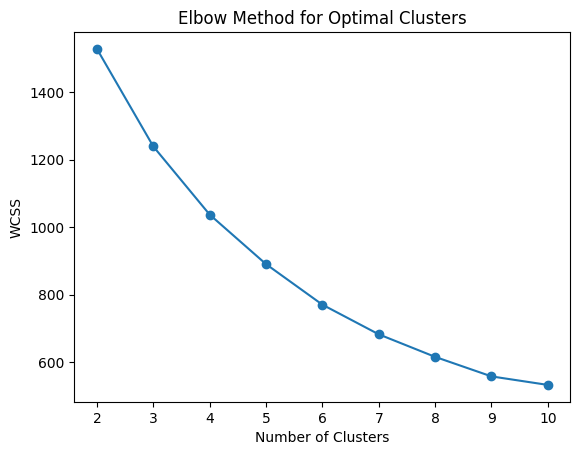

In [39]:
plt.figure()

plt.plot(
    range(2, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Clusters")

plt.show()

In [40]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

In [41]:
score = silhouette_score(
    scaled_data,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.44751166087215305


In [42]:
best_score = 0
best_k = 0

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print("Clusters:", k, "Score:", score)

    if score > best_score:
        best_score = score
        best_k = k

print("\nBest Cluster:", best_k)
print("Best Silhouette Score:", best_score)

Clusters: 2 Score: 0.44751166087215305
Clusters: 3 Score: 0.36351361779009067
Clusters: 4 Score: 0.3909627794318319
Clusters: 5 Score: 0.3338979398770868
Clusters: 6 Score: 0.3247494403575592
Clusters: 7 Score: 0.34373134578788256
Clusters: 8 Score: 0.34978138448396145
Clusters: 9 Score: 0.35946910735783627
Clusters: 10 Score: 0.3526513080860649

Best Cluster: 2
Best Silhouette Score: 0.44751166087215305


In [43]:
print(df["Cluster"].value_counts())

Cluster
0    181
1     33
Name: count, dtype: int64


In [44]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

print(cluster_centers)

         RI        Na        Mg        Al        Si         K        Ca  \
0  0.090974 -0.226441  0.288175 -0.279826 -0.016009 -0.030968  0.063465   
1 -0.498978  1.241997 -1.580597  1.534802  0.087809  0.169856 -0.348096   

         Ba        Fe  
0 -0.331159  0.068843  
1  1.816355 -0.377595  


In [45]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

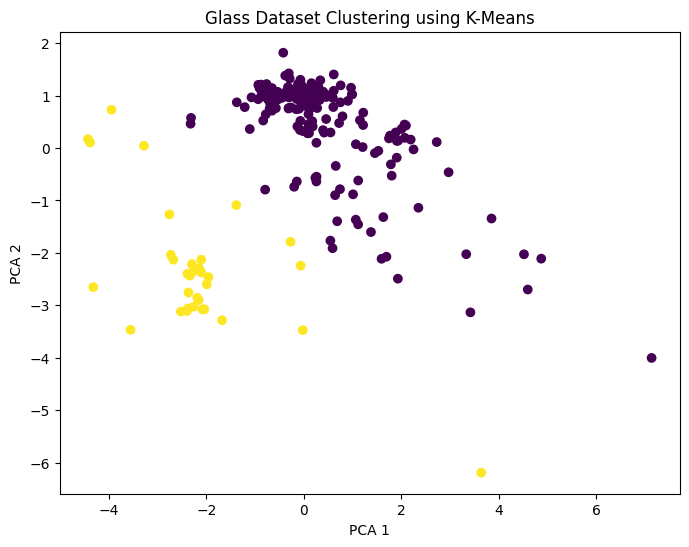

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"]
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Glass Dataset Clustering using K-Means")

plt.show()

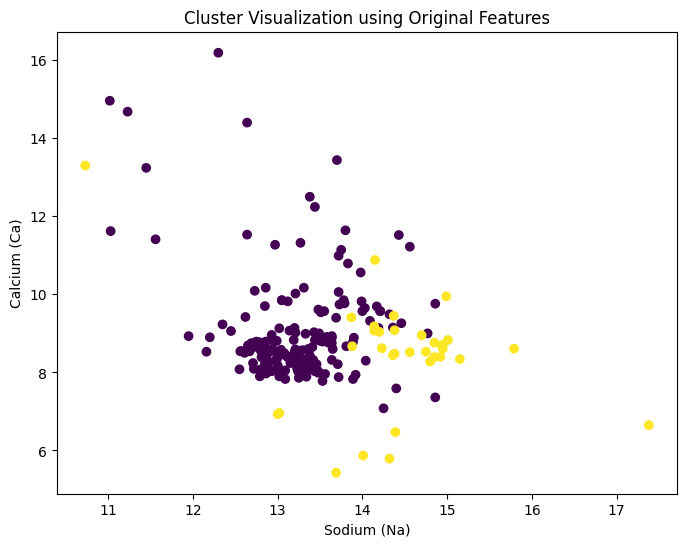

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Na"],
    df["Ca"],
    c=df["Cluster"]
)

plt.xlabel("Sodium (Na)")
plt.ylabel("Calcium (Ca)")
plt.title("Cluster Visualization using Original Features")

plt.show()